In [1]:
import sqlite3, pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
con = sqlite3.connect('rubin_obs_orbits.sqlite')

In [3]:
cmd = "select * from obs_sbn ORDER BY RANDOM() LIMIT 1"

lsst_discovery_orbits = pd.read_sql_query(cmd, con)

In [4]:
lsst_discovery_orbits

,id,trksub,trkid,obsid,submission_id,submission_block_id,obs80,status,ref,healpix,...,shapeocc,obssubid,replacesobsid,group_id,vel1,fltr,vel3,vel2,obstime_text,mjd_utc
0,567555334,cb00245,00000Isey1,LorDdACC0000Gugo0100004DX,2025-06-23T14:33:20.756_0000Gugo,2025-06-23T14:33:20.756_0000Gugo_01,K25M72D 0C2025 05 04.15064412 24 44.159+0...,P,MPS 2388746,7265053397,...,None,24633520328015900,None,None,None,None,None,None,2025-05-04T03:36:55.621Z,60799.150644


In [5]:
lsst_discovery_orbits.keys()

Index(['id', 'trksub', 'trkid', 'obsid', 'submission_id',
       'submission_block_id', 'obs80', 'status', 'ref', 'healpix', 'permid',
       'provid', 'artsat', 'mode', 'stn', 'trx', 'rcv', 'sys', 'ctr', 'pos1',
       'pos2', 'pos3', 'poscov11', 'poscov12', 'poscov13', 'poscov22',
       'poscov23', 'poscov33', 'prog', 'obstime', 'ra', 'dec', 'rastar',
       'decstar', 'obscenter', 'deltara', 'deltadec', 'dist', 'pa', 'rmsra',
       'rmsdec', 'rmsdist', 'rmspa', 'rmscorr', 'delay', 'rmsdelay', 'doppler',
       'rmsdoppler', 'astcat', 'mag', 'rmsmag', 'band', 'photcat', 'photap',
       'nucmag', 'logsnr', 'seeing', 'exp', 'rmsfit', 'com', 'frq', 'disc',
       'subfrm', 'subfmt', 'prectime', 'precra', 'precdec', 'unctime', 'notes',
       'remarks', 'deprecated', 'localuse', 'nstars', 'prev_desig', 'prev_ref',
       'rmstime', 'created_at', 'updated_at', 'trkmpc', 'orbit_id',
       'designation_asterisk', 'shapeocc', 'obssubid', 'replacesobsid',
       'group_id', 'vel1', 'fltr'

In [6]:

#cmd = "select obstime, provid, mag, rmsmag, band, a,e, incl from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where a > 20"

cmd = "select distinct provid, a,e, incl from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where e < 1 and a >= 1.6 and a <= 4.2 and a/(1-e)>=1.3"

lsst_discovery_orbits = pd.read_sql_query(cmd, con)



In [7]:
lsst_discovery_orbits.shape[0]

86792

Text(0, 0.5, 'inclination (degrees)')

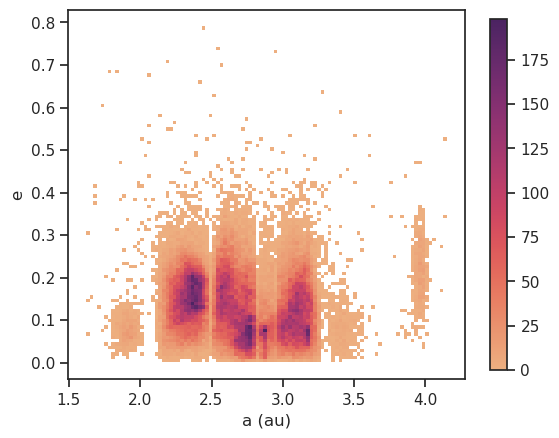

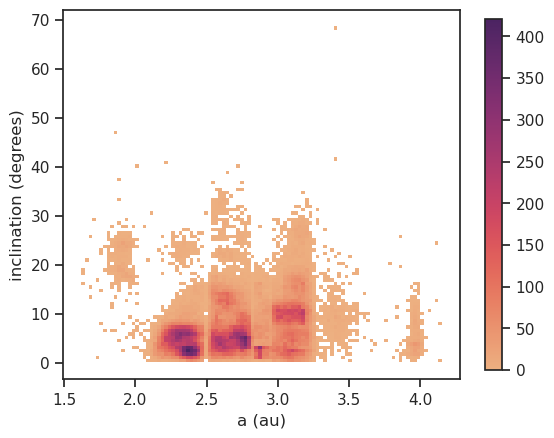

In [8]:
sns.set(style="ticks")
plt.figure()
sns.histplot(x=lsst_discovery_orbits['a'], y=lsst_discovery_orbits['e'], bins=100, cmap="flare",  cbar=True, cbar_kws=dict(shrink=.95))
plt.xlabel('a (au)')
plt.ylabel('e')

plt.figure()

sns.histplot(x=lsst_discovery_orbits['a'], y=lsst_discovery_orbits['incl'], bins=100, cmap="flare",  cbar=True, cbar_kws=dict(shrink=.95))
plt.xlabel('a (au)')
plt.ylabel('inclination (degrees)')

Text(0, 0.5, 'e')

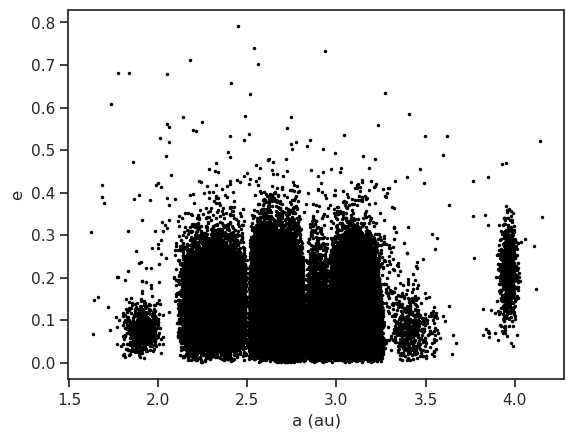

In [9]:
plt.figure()
plt.plot(lsst_discovery_orbits['a'], lsst_discovery_orbits['e'], '.',markersize=3, color='black')
plt.xlabel('a (au)')
plt.ylabel('e')


Text(0, 0.5, 'inc (deg)')

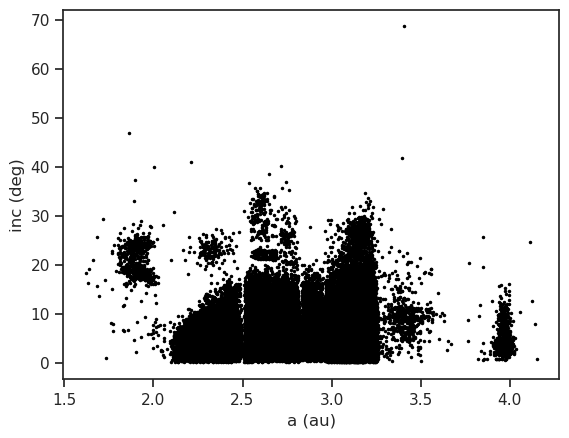

In [10]:
plt.figure()
plt.plot(lsst_discovery_orbits['a'], lsst_discovery_orbits['incl'], '.',markersize=3, color='black')
plt.xlabel('a (au)')
plt.ylabel('inc (deg)')


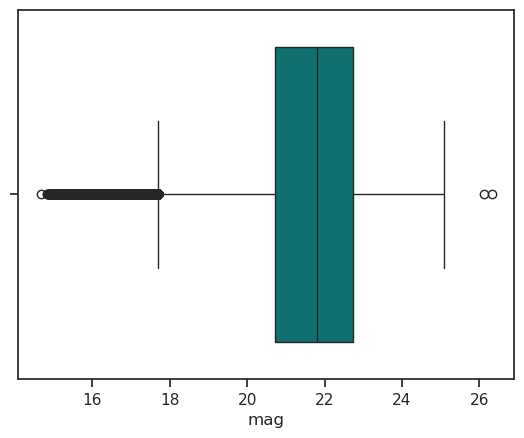

In [11]:
cmd = "select provid, mag, obstime, mjd_utc from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where e < 1 and a >= 1.6 and a <= 4.2 and a/(1-e)>=1.3"

dfObs = pd.read_sql_query(cmd, con)
plt.figure()
ax = sns.boxplot(x=dfObs['mag'], color='Teal')

In [12]:
faint_mags= dfObs.loc[dfObs['mag'] > 25]

In [13]:
faint_mags

,provid,mag,obstime,mjd_utc
586027,2025 MN61,25.098,2025-04-25T04:27:40.253000,60790.185883
609107,2025 MY17,26.115,2025-05-02T02:23:37.437000,60797.099739
840932,2025 MW39,25.037,2025-05-04T02:31:39.498000,60799.105318
1407065,2025 MU78,26.321,2025-05-02T01:28:36.344000,60797.061532


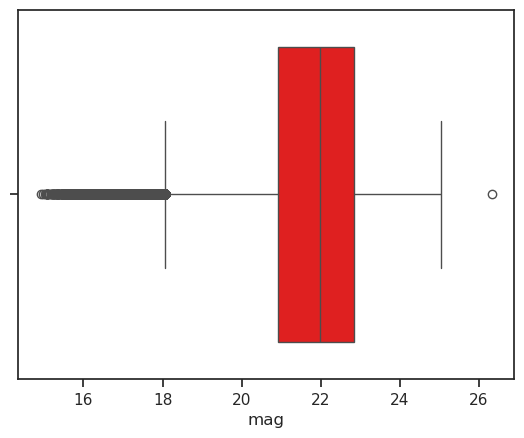

In [14]:
cmd = "select provid, mag, obstime, mjd_utc from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where  band ='Lr' and e < 1 and a >= 1.6 and a <= 4.2 and a/(1-e)>=1.3"

dfObs = pd.read_sql_query(cmd, con)
plt.figure()
ax = sns.boxplot(x=dfObs['mag'], color='red')

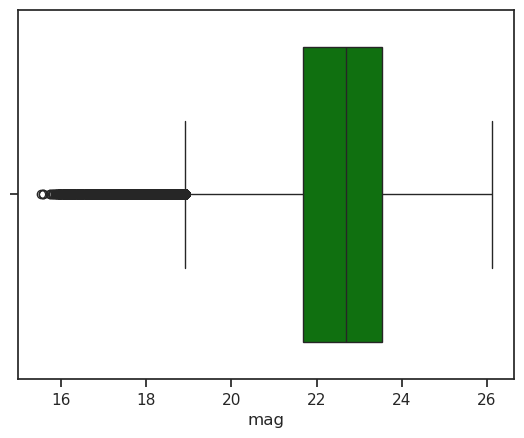

In [15]:
cmd = "select provid, mag, obstime, mjd_utc from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where  band ='Lg' and e < 1 and a >= 1.6 and a <= 4.2 and a/(1-e)>=1.3"

dfObs = pd.read_sql_query(cmd, con)
plt.figure()
ax = sns.boxplot(x=dfObs['mag'], color='green')

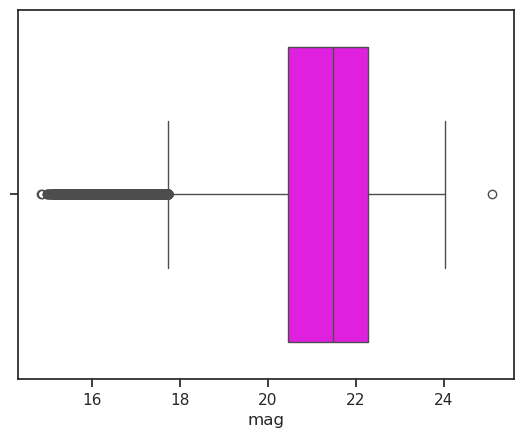

In [16]:

cmd = "select provid, mag, obstime, mjd_utc from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where  band ='Li' and e < 1 and a >= 1.6 and a <= 4.2 and a/(1-e)>=1.3"

dfObs = pd.read_sql_query(cmd, con)
plt.figure()
ax = sns.boxplot(x=dfObs['mag'], color='magenta')

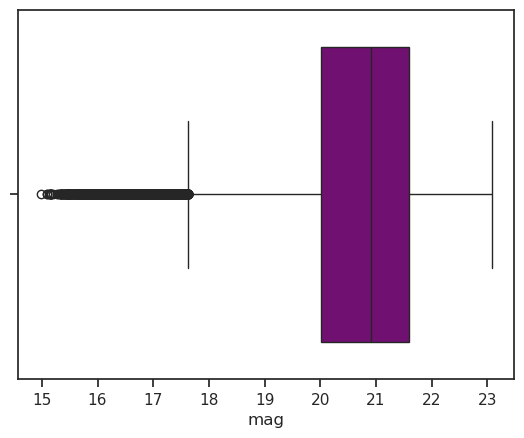

In [17]:
cmd = "select provid, mag, obstime, mjd_utc from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where  band ='Lz' and e < 1 and a >= 1.6 and a <= 4.2 and a/(1-e)>=1.3"

dfObs = pd.read_sql_query(cmd, con)
plt.figure()
ax = sns.boxplot(x=dfObs['mag'], color='purple')

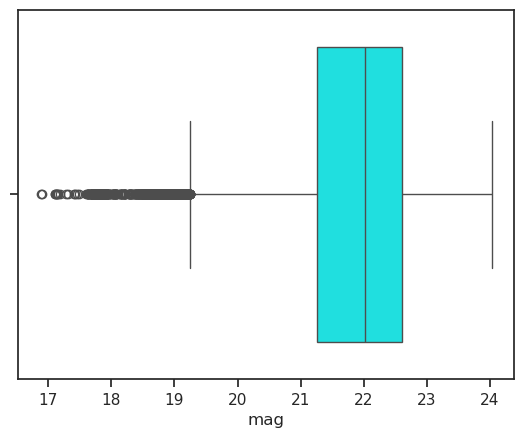

In [18]:
cmd = "select provid, mag, obstime, mjd_utc from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where  band ='Lu' and e < 1 and a >= 1.6 and a <= 4.2 and a/(1-e)>=1.3"

dfObs = pd.read_sql_query(cmd, con)
plt.figure()
ax = sns.boxplot(x=dfObs['mag'], color='cyan')
plt.show()

In [19]:
dfObs.shape[0]

32361

In [20]:
plt.close('all') 
